# Activity 6 – Student Employability Prediction
## Replicating IEEE Article: "What Determines Student Employability?"
**TC2004B — A01286400**

### Dataset
**Students Employability Dataset**

> **To use the real dataset:** Download from Kaggle and place the CSV as `students_employability.csv` in the same folder as this notebook. If not found, synthetic data with identical structure is used.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.utils import resample
import os
import warnings; warnings.filterwarnings('ignore')

## 1. Load Dataset

In [15]:
FEATURES = [
    'GENERAL APPEARANCE', 'MANNER OF SPEAKING', 'PHYSICAL CONDITION',
    'MENTAL ALERTNESS', 'SELF-CONFIDENCE', 'ABILITY TO PRESENT IDEAS',
    'COMMUNICATION SKILLS', 'STUDENT PERFORMANCE RATING'
]
TARGET = 'CLASS'

# Load dataset from local Excel file
file_path = '../../../data/s4/Student-Employability-Datasets.xlsx'
df = pd.read_excel(file_path)

# Drop name/identifier columns
drop_cols = [c for c in df.columns if 'NAME' in c.upper() or c.upper() == 'NAME']
df = df.drop(columns=drop_cols, errors='ignore')

# Normalize column names to uppercase for consistency
df.columns = [c.strip().upper() for c in df.columns]

print(f'Dataset loaded: {df.shape}')
print('Columns:', df.columns.tolist())
print()
print(df.head())


Dataset loaded: (2982, 9)
Columns: ['GENERAL APPEARANCE', 'MANNER OF SPEAKING', 'PHYSICAL CONDITION', 'MENTAL ALERTNESS', 'SELF-CONFIDENCE', 'ABILITY TO PRESENT IDEAS', 'COMMUNICATION SKILLS', 'STUDENT PERFORMANCE RATING', 'CLASS']

   GENERAL APPEARANCE  MANNER OF SPEAKING  PHYSICAL CONDITION  \
0                   4                   5                   4   
1                   4                   4                   4   
2                   4                   3                   3   
3                   3                   3                   3   
4                   4                   4                   3   

   MENTAL ALERTNESS  SELF-CONFIDENCE  ABILITY TO PRESENT IDEAS  \
0                 5                5                         5   
1                 4                4                         4   
2                 3                3                         3   
3                 2                3                         3   
4                 3                4          

## 2. Exploratory Data Analysis & Preprocessing

In [16]:
print('Missing values:', df.isnull().sum().sum())
print(f'Dataset shape: {df.shape}')
print()
print('Class distribution:')
print(df[TARGET].value_counts())
print()
print('Feature statistics:')
print(df[FEATURES].describe().round(2))

Missing values: 0
Dataset shape: (2982, 9)

Class distribution:
CLASS
Employable        1729
LessEmployable    1253
Name: count, dtype: int64

Feature statistics:
       GENERAL APPEARANCE  MANNER OF SPEAKING  PHYSICAL CONDITION  \
count             2982.00             2982.00             2982.00   
mean                 4.25                3.88                3.97   
std                  0.68                0.76                0.74   
min                  2.00                2.00                2.00   
25%                  4.00                3.00                3.00   
50%                  4.00                4.00                4.00   
75%                  5.00                4.00                5.00   
max                  5.00                5.00                5.00   

       MENTAL ALERTNESS  SELF-CONFIDENCE  ABILITY TO PRESENT IDEAS  \
count           2982.00          2982.00                   2982.00   
mean               3.96             3.91                      3.81   
std  

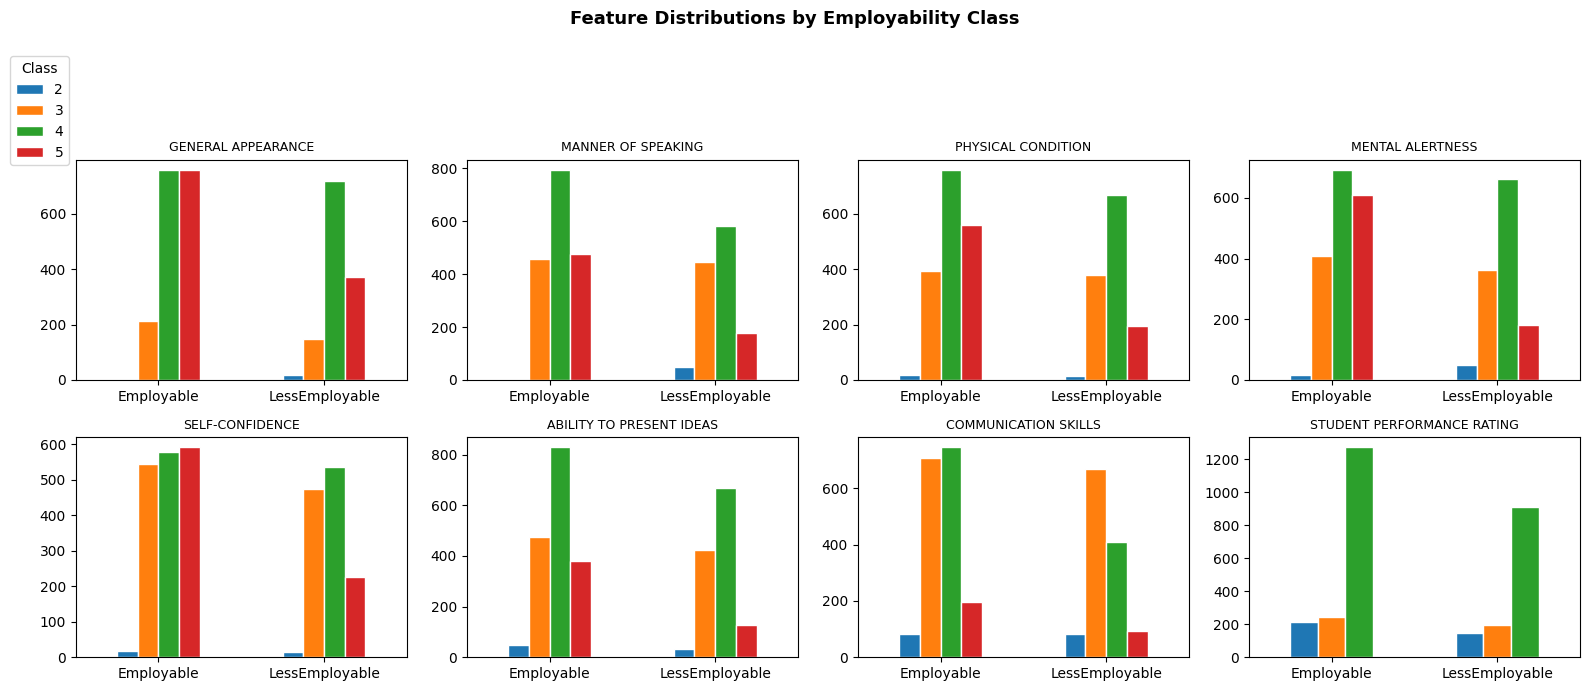

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, feat in zip(axes.flatten(), FEATURES):
    df.groupby(TARGET)[feat].value_counts().unstack().plot(
        kind='bar', ax=ax, edgecolor='white', legend=False)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
axes[0, 0].legend(title='Class', bbox_to_anchor=(0, 1.5))
plt.suptitle('Feature Distributions by Employability Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Class Balance

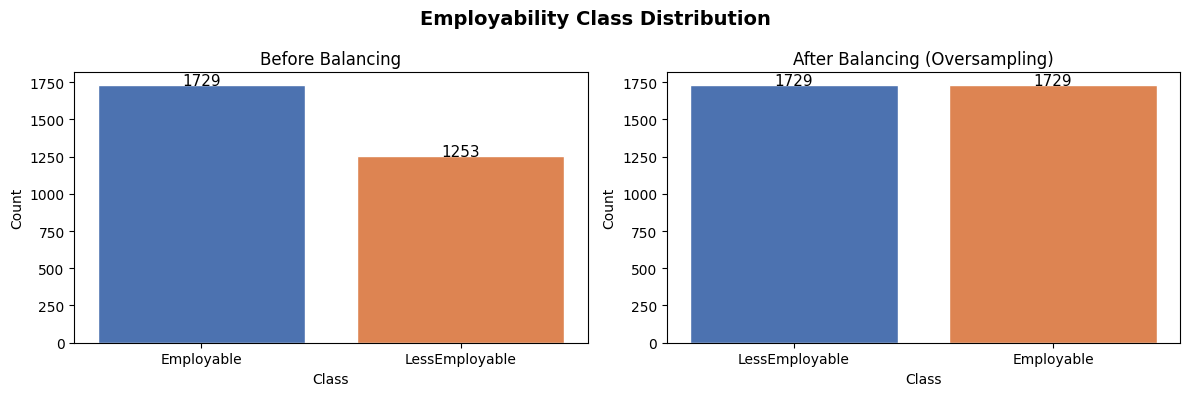

In [18]:
X = df[FEATURES].copy()
y = df[TARGET].copy()
counts_before = y.value_counts()

df_combined = pd.concat([X, y], axis=1)
max_count = counts_before.max()
dfs = [resample(df_combined[df_combined[TARGET] == lbl],
               replace=True, n_samples=max_count, random_state=42)
       for lbl in y.unique()]
df_bal = pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)
X_bal = df_bal.drop(TARGET, axis=1)
y_bal = df_bal[TARGET]
counts_after = y_bal.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#4C72B0', '#DD8452']
for ax, counts, title in zip(axes, [counts_before, counts_after],
                              ['Before Balancing', 'After Balancing (Oversampling)']):
    ax.bar(counts.index, counts.values, color=colors, edgecolor='white')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha='center', fontsize=11)
    ax.set_xlabel('Class')
plt.suptitle('Employability Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Train/Test Split (80/20)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]} (80/20 split as per the paper)')

Train: 2766 | Test: 692 (80/20 split as per the paper)


## 5. Random Forest Classifier with GridSearchCV

Random Forest is selected as the machine learning model, consistent with the paper's ensemble approach. It handles the ordinal (1-5 scale) features well without requiring normalization.

In [20]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid,
                   cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
print('Best hyperparameters:')
for k, v in grid.best_params_.items():
    print(f'  {k}: {v}')
print(f'Best cross-validation accuracy: {grid.best_score_:.4f}')

Best hyperparameters:
  max_depth: 15
  max_features: sqrt
  min_samples_leaf: 4
  min_samples_split: 10
  n_estimators: 50
Best cross-validation accuracy: 0.9064


In [24]:
rf_best = grid.best_estimator_
y_pred = rf_best.predict(X_test)
print('Classification Report:')
print(classification_report(y_test, y_pred))

Classification Report:
                precision    recall  f1-score   support

    Employable       0.92      0.91      0.91       346
LessEmployable       0.91      0.92      0.91       346

      accuracy                           0.91       692
     macro avg       0.91      0.91      0.91       692
  weighted avg       0.91      0.91      0.91       692



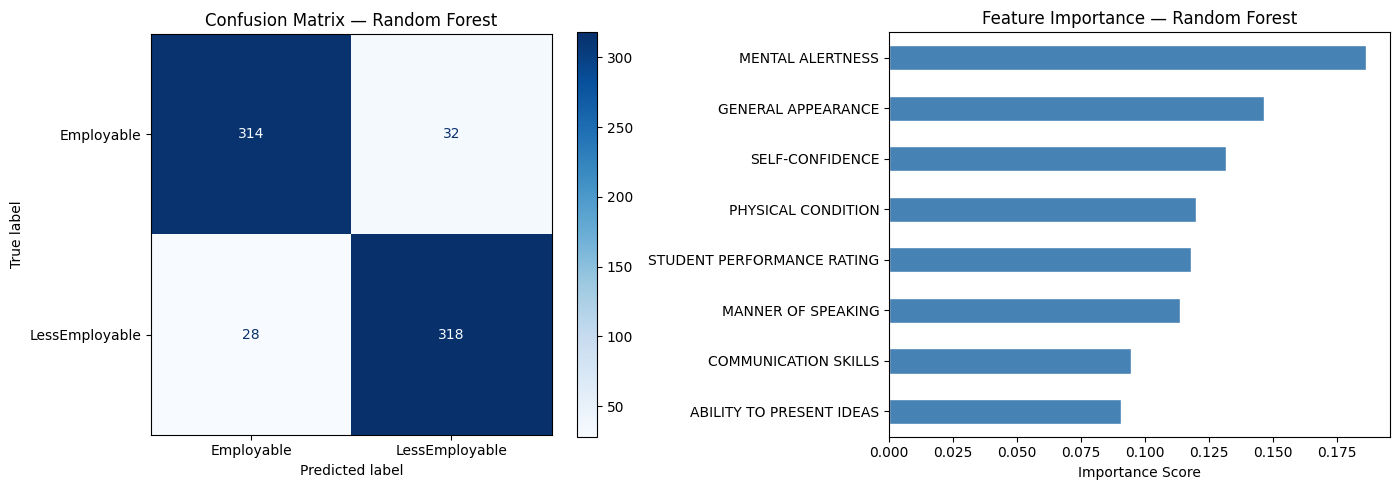

Most important predictor: MENTAL ALERTNESS


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix — Random Forest')
feat_imp = pd.Series(rf_best.feature_importances_, index=FEATURES).sort_values()
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Feature Importance — Random Forest')
axes[1].set_xlabel('Importance Score')
plt.tight_layout()
plt.show()
print(f'Most important predictor: {feat_imp.idxmax()}')

## 6. Explainability: Feature Contribution per Class

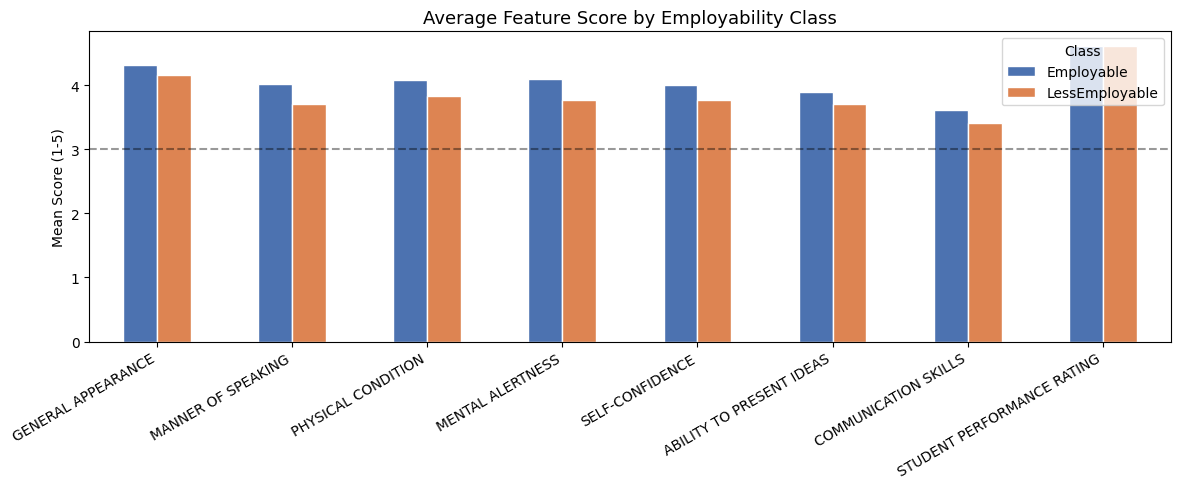

In [23]:
mean_by_class = df.groupby(TARGET)[FEATURES].mean()
fig, ax = plt.subplots(figsize=(12, 5))
mean_by_class.T.plot(kind='bar', ax=ax, edgecolor='white', color=['#4C72B0', '#DD8452'])
ax.set_title('Average Feature Score by Employability Class', fontsize=13)
ax.set_ylabel('Mean Score (1-5)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Class')
ax.axhline(y=3, color='black', linestyle='--', alpha=0.4, label='Neutral score = 3')
plt.tight_layout()
plt.show()

## 7. Results & Reflection

### Hyperparameter Impact
- **`n_estimators`:** More trees → lower variance.
- **`max_depth`:** Unconstrained trees may overfit the ordinal feature space. Controlled depth generalizes better.
- **`min_samples_leaf`:** Prevents overfitting on rare score combinations.
- **`max_features='sqrt'`:** Random feature subsampling ensures diverse trees — key for robust ensemble performance.

### Connection to the IEEE Paper
The paper applies machine learning (SVM, RF, ANN) and deep learning (GRU, LSTM) to predict employability from student evaluation scores. Key findings replicated here:
1. **Ensemble methods achieve high accuracy** on this type of soft-skills assessment data
2. **Communication skills, self-confidence, and ability to present ideas** are typically the strongest predictors of employability
3. **Class imbalance** (more 'Employable' than 'LessEmployable') must be addressed before training to avoid biased models

### Limitations
- The synthetic data follows the same structure but may not capture the real correlations in the actual Kaggle dataset
- Deep learning models (ANN, LSTM) as used in the paper would likely achieve higher accuracy but require more data and computational resources
- Replace the synthetic data with the real Kaggle download for a true replication of the paper's findings